In [35]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../..')))

In [36]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

In [37]:
def prox(x, model, sigma=None):
    """
    Evaluate the learned proximal operator at x.

    Params:
    x (numpy): (b, *), b inputs for LPN model, the shape of each input should match the input shape of the model
    model: LPN_cond model

    Returns:
    y (numpy): (b, *), b outputs from LPN model
    """
    device = next(model.parameters()).device
    x = torch.from_numpy(x).float().to(device)

    #LPN
    if sigma is None:
        return model(x).detach().cpu().numpy()
    
    #LPN_cond
    b = x.size(0)
    noise_levels = torch.full((b,1), sigma, device=device)
    return model(x, noise_levels).detach().cpu().numpy()

def torch_f_cg(x, model, z, sigma=None):
    """
    Compute the value of the objective function:
    psi(x) - <z, x>

    Params:
    x (tensor): (*) should match the input shape of the model
    model: ICNN
    z (tensor): (*) should match the input shape of the model
    
    Return: 
    v (tensor): shape (1,), objective function value
    """
    device = next(model.parameters()).device

    x = x.to(device)
    z = z.to(device)
    
    if sigma is None:
        v = model.scalar(x.unsqueeze(0)).squeeze() - torch.sum(z.reshape(-1) * x.reshape(-1))
    else:
        noise_levels = torch.tensor([[sigma]], dtype=torch.float32, device=device)
        v = model.scalar(x.unsqueeze(0), noise_levels).squeeze() - torch.sum(z.reshape(-1) * x.reshape(-1))
    return v

def f(x, *args):
    """
    Objective function for invert_cvx_cg, i.e. f(x) = psi_theta(x) - <z,x>

    Params:
    x (numpy): (n,), flattened model input
    args: (model, z, sigma)
        model: LPN model
        z (numpy): (*), single input for inverse evaluation, the shape of each input should match the input shape of the model
        state (dict) or None: optional state dict for tracking objective values
        sigma (float) or None: conditional noise

    Return:
    v (numpy): float objective function value evaluated at x
    """
    model, z, state, sigma = args

    device = next(model.parameters()).device
    x = torch.from_numpy(x.copy()).float().to(device).view(z.shape)
    z = torch.from_numpy(z.copy()).float().to(device)
    
    v = torch_f_cg(x, model, z, sigma=sigma)
    v_np = v.cpu().detach().numpy()
    obj_val = float(np.array(v_np).reshape(()))

    if state is not None:
        state['last_obj'] = obj_val

    return obj_val

def gradf(x, *args):
    """
    Gradient of the objective function for invert_cvx_cg

    Params:
    x (numpy): (n,), flattened model input
    args: (model, z)
        model: LPN model
        z (numpy): (*), single input for inverse evaluation, the shape of each input should match the input shape of the model
        sigma (float) or None: conditional noise
        state (dict) or None: optional state dict (not used in gradient, but needed for consistent signature)

    Return:
    g (numpy): (n), flattened gradient
    """
    model, z, state, sigma = args

    device = next(model.parameters()).device

    x = torch.from_numpy(x.copy()).float().to(device).view(z.shape)
    x.requires_grad_(True)

    z = torch.from_numpy(z.copy()).float().to(device)

    v = torch_f_cg(x, model, z, sigma=sigma)
    v.backward()

    g = x.grad.cpu().numpy().flatten()
    return np.asarray(g, dtype=np.float64)

def compute_metrics(xk, z, model, sigma):
    """
    Compute objective value and MSE at current iterate.
    
    Params:
    xk (numpy): (n,), flattened current iterate
    z (numpy): (*), target input
    model: LPN model
    sigma: noise level
    
    Returns:
    obj_val (float): objective function value
    mse (float): MSE between prox(xk) and z
    """
    # Compute objective
    obj_val = f(xk, model, z, None, sigma)
    
    # Compute MSE
    yi = np.asarray(xk).reshape(z.shape)
    prox_out = prox(np.expand_dims(yi, 0), model, sigma=sigma)
    mse = float(np.mean((prox_out - z) ** 2))
    
    return obj_val, mse

def invert_cvx_cg(x, model, sigma=None, maxiter=200, logger=None,
                  dense_iters=20, sparse_every=10, save_path=None):
    """Invert the LPN model at x by convex optimization with CG.
    Solve min_y psi_theta(y) - <x,y>
    
    Params:
    x (numpy): (b, *), b inputs for LPN model, the shape of each input should match the input shape of the model
    model: LPN model.
    sigma (float or None): conditional noise
    maxiter (int): maximum iterations
    logger: optional logger
    dense_iters (int): record every iteration for the first dense_iters iterations
    sparse_every (int): after dense_iters, record every sparse_every iterations
    save_path (str or None): if provided, save history to this CSV file (without extension, 
                              will create {save_path}.csv, {save_path}_obj.csv and {save_path}_mse.csv)
    
    Returns:
    y (numpy): (b, *), b outputs, inverse of LPN model at x
    """
    y = np.zeros(x.shape)
    all_records = []

    if save_path is not None:
        # create folder if it doesn't exist
        save_dir = os.path.dirname(save_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir, exist_ok=True)
    
    for i in range(x.shape[0]):
        z = x[i].copy()
        x0 = z.copy().flatten()

        state = {
            'iter': 0,
            'last_obj': None,  
            'history': []
        }

        # Compute and record initial metrics at iter 0
        init_obj, init_mse = compute_metrics(x0, z, model, sigma)
        state['history'].append({
            'iter': 0,
            'objective': init_obj,
            'mse': init_mse
        })
        
        args = (model, z, state, sigma)
        
        def _scipy_callback(xk):
            state['iter'] += 1
            current_iter = state['iter']
            
            should_record = (current_iter <= dense_iters) or (current_iter % sparse_every == 0)

            if not should_record:
                return
            
            # Compute metrics
            obj_val, mse = compute_metrics(xk, z, model, sigma)
            
            state['history'].append({
                'iter': current_iter,
                'objective': obj_val,
                'mse': mse
            })

        # run optimizer
        res = minimize(
            f, x0, args=args, method='CG', jac=gradf,
            callback=_scipy_callback,
            options={'maxiter': maxiter, 'gtol': 1e-5, 'disp': False}
        )
        
        # Compute final metrics
        final_y = res.x.reshape(z.shape)
        final_obj, final_mse = compute_metrics(res.x, z, model, sigma)
        
        # Add final iteration if not already recorded
        if not state['history'] or state['history'][-1]['iter'] != state['iter']:
            state['history'].append({
                'iter': state['iter'],
                'objective': final_obj,
                'mse': final_mse
            })

        # use final result
        y[i] = final_y

        # collect records for this sample
        for record in state['history']:
            all_records.append({
                'sample': i,
                'iter': record['iter'],
                'objective': record['objective'],
                'mse': record['mse']
            })
        
        # logging
        if logger:
            logger.info(f"Sample {i}: {len(state['history'])} checkpoints, "
                       f"converged at iter {state['iter']}, "
                       f"final_obj={final_obj:.6e}, final_mse={final_mse:.6e}")
            # Show initial and final
            logger.info(f"  Initial (iter 0): obj={init_obj:.4e}, mse={init_mse:.4e}")
            logger.info(f"  Final (iter {state['iter']}): obj={final_obj:.4e}, mse={final_mse:.4e}")

    # final batch MSE
    final_batch_mse = np.mean((prox(y, model, sigma=sigma) - x) ** 2)
    print(f"Final batch MSE: {final_batch_mse:.6e}")
    if logger is not None:
        logger.info(f"Final batch MSE: {final_batch_mse:.6e}")

    # save history to CSV if path provided
    if save_path is not None and all_records:
        df = pd.DataFrame(all_records)
        
        # Save combined file
        combined_path = f"{save_path}.csv"
        df.to_csv(combined_path, index=False)
        print(f"History saved to {combined_path}")
        
        # Pivot table for objective values (samples as columns)
        df_obj = df.pivot(index='iter', columns='sample', values='objective')
        df_obj.to_csv(f"{save_path}_obj.csv")
        
        # Pivot table for MSE values (samples as columns)
        df_mse = df.pivot(index='iter', columns='sample', values='mse')
        df_mse.to_csv(f"{save_path}_mse.csv")
        
        print(f"Objective history saved to {save_path}_obj.csv")
        print(f"MSE history saved to {save_path}_mse.csv")
    
    return y

def invert(x, model, inv_alg, sigma, **kwargs):
    """
    Invert the LPN model at x.

    Params:
    x (numpy): (b,*), b inputs for LPN model, the shape of each input should match the input shape of the model
    model: LPN model
    inv_alg: Inversion algorithm, choose from ['ls', 'cvx_cg', 'cvx_gd']

    Returns:
    y (numpy): (b,*), b outputs, inverse of LPN model at x
    """
    if inv_alg == "ls":
        pass
    elif inv_alg == "cvx_cg":
        return invert_cvx_cg(x, model, sigma=sigma, **kwargs)
    elif inv_alg == "cvx_gd":
        pass
    else:
        raise ValueError("Unknown inversion algorithm:", inv_alg)

In [38]:
def eval_lpn_prior(x, model, inv_alg, sigma, **kwargs):
    """
    Evaluate the learned prior at x.

    Params:
        x: (b, *), b inputs for LPN model, the shape of each input should match the input shape of the model
        model: LPN model
        inv_alg: Inversion algorithm, choose from ['ls', 'cvx_cg', 'cvx_gd']
        sigma (float or None): conditional noise

    Returns:
        p: (b, ), numpy.ndarray, the prior value at x
        y: (b, *), numpy.ndarray, the inverse of model at x
        fy: (b, *), numpy.ndarray, the model output at y

    Note: The shape of x should match the input shape of model.

    Formula: phi(f(y)) = <y, f(y)> - 1/2 ||f(y)||^2 - psi(y)

    """
    b = x.shape[0]
    device = next(model.parameters()).device

    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
        
    # invert 
    y = invert(x, model, inv_alg, sigma=sigma, **kwargs)
    y_torch = torch.tensor(y).float().to(device)
    if sigma is None:
        fy = model(y_torch).detach().cpu().numpy()
        psi = model.scalar(y_torch).squeeze(1).detach().cpu().numpy()
    else:
        noise_levels = torch.full((b,1), sigma).to(device)
        fy = model(y_torch, noise_levels).detach().cpu().numpy()
        psi = model.scalar(y_torch, noise_levels).squeeze(1).detach().cpu().numpy()

    # compute prior
    q = 0.5 * np.sum(x.reshape(b,-1)**2, axis=1)
    ip = np.sum(y.reshape(b,-1) * x.reshape(b,-1), axis=1)
    p = ip - q - psi

    return p,y,fy

In [39]:
if torch.backends.mps.is_available():
    # mps backend is used in Apple Silicon chips
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(device)

cuda


In [40]:
from lpn_mrs.datasets import MRSDataset
dataset = MRSDataset('../data/', split='test', data_type='clean')
sample = np.array([dataset[i] for i in range(30)])
batch = torch.tensor(sample, device=device).unsqueeze(1)

In [41]:
from lpn_mrs.networks import LPN_cond
model = LPN_cond(
        in_dim=1,
        hidden_c=1,
        hidden=32,
        kernel=3,
        beta=10,
        alpha=1e-6
    )
model.load_state_dict(torch.load(f"../weights/lpn_cond_mrs_h_32_k_3_n_(0.05_0.2)/LPN_best.pt"))
model = model.to(device)

In [42]:
p, y, fy = eval_lpn_prior(batch, model, inv_alg='cvx_cg', sigma=0.1, maxiter=20, logger = None, save_path = '../savings/lpn_cond_mrs_h_32_k_3_n_(0.05_0.2)')

Final batch MSE: 1.911069e-02
History saved to ../savings/lpn_cond_mrs_h_32_k_3_n_(0.05_0.2).csv
Objective history saved to ../savings/lpn_cond_mrs_h_32_k_3_n_(0.05_0.2)_obj.csv
MSE history saved to ../savings/lpn_cond_mrs_h_32_k_3_n_(0.05_0.2)_mse.csv


/tmp/ipykernel_3543314/1856040169.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


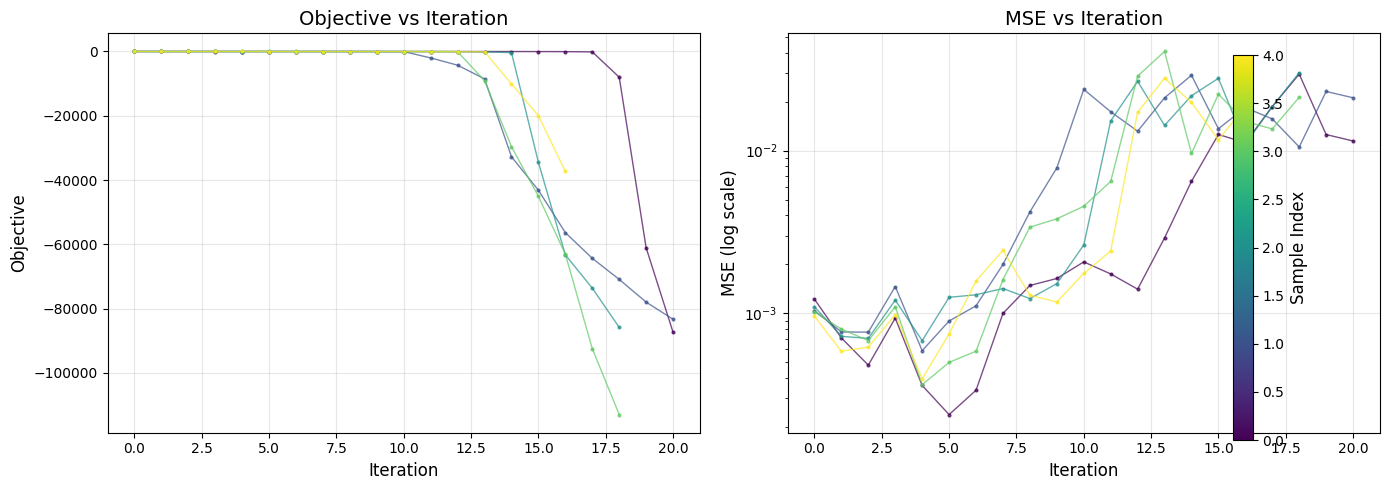

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../savings/lpn_cond_mrs_h_32_k_3_n_(0.05_0.2).csv')
# Get unique samples
samples = df['sample'].unique()[:5]

# Create figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use a colormap that supports many colors
colors = plt.cm.viridis(np.linspace(0, 1, len(samples)))

# Plot Objective
ax1 = axes[0]
for idx, sample in enumerate(samples):
    sample_data = df[df['sample'] == sample]
    ax1.plot(sample_data['iter'], sample_data['objective'], 
             marker='o', markersize=2, linewidth=1,
             color=colors[idx], alpha=0.7)

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Objective', fontsize=12)
ax1.set_title('Objective vs Iteration', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot MSE (log scale)
ax2 = axes[1]
for idx, sample in enumerate(samples):
    sample_data = df[df['sample'] == sample]
    ax2.plot(sample_data['iter'], sample_data['mse'], 
             marker='o', markersize=2, linewidth=1,
             color=colors[idx], alpha=0.7)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('MSE (log scale)', fontsize=12)
ax2.set_title('MSE vs Iteration', fontsize=14)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Add a colorbar to indicate sample index
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=len(samples)-1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Sample Index', fontsize=12)

plt.tight_layout()
plt.savefig('optimization_history.png', dpi=150, bbox_inches='tight')
plt.show()